# Notebook 4 — Bubble Diagnostics

This notebook computes the bubble existence conditions from **Theorem 1** and **Corollary 1** of `V7_Theorem_Conditions.tex`:

1. **Leakage ratio** $a_t$ (proof of Theorem 1, V7)
2. **Theorem 1 conditions**:
   - (1a): $\sum D_t^u / Q_t^u < \infty$
   - (1b): $\sum \frac{(Q_t^b+D_t^b)/(C_t^b)^\gamma}{Q_t^u/(C_t^u)^\gamma} < \infty$
3. **Corollary 1 primitive conditions** (equivalent under equilibrium bounds from Lemmas 1–6, V7):
   - (2a): $\sum D_t^u / e_{US,t}^u < \infty$
   - (2b): $\sum (e_t^b / e_t^u)^{1-\gamma} < \infty$
4. **Fundamental value** decomposition: $Q_{US,t} = V_t + B_t$
5. Diagnostic plots and leakage analysis

In [44]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT`


Plots.GRBackend()

In [45]:
# ── Run the full simulation ──
result = run_simulation(ModelParams(); verbose=true);

Generating exogenous paths...
Solving balanced-growth states...
  t= 20: ω_b=0.6315  θ_b=-1.679956  R_f_b=1.0783
  t= 40: ω_b=0.6315  θ_b=-1.679956  R_f_b=1.0783
  t= 60: ω_b=0.6315  θ_b=-1.679956  R_f_b=1.0783
  t= 80: ω_b=0.6315  θ_b=-1.679956  R_f_b=1.0783
  t=100: ω_b=0.6315  θ_b=-1.679956  R_f_b=1.0783
  t=120: ω_b=0.6315  θ_b=-1.679956  R_f_b=1.0783
Solving u-path by backward induction...
  t=110: ω=0.7526  θ=-0.000073  θ*_US=+0.0248  R_f=0.1381  q_US=0.376569  ‖F‖=6.9e-17
  t=100: ω=0.7295  θ=-0.000172  θ*_US=+0.0280  R_f=0.1911  q_US=0.365329  ‖F‖=1.1e-16
  t= 90: ω=0.7075  θ=-0.000413  θ*_US=+0.0323  R_f=0.2601  q_US=0.354809  ‖F‖=5.4e-14
  t= 80: ω=0.6825  θ=-0.001019  θ*_US=+0.0381  R_f=0.3469  q_US=0.343311  ‖F‖=2.0e-15
  t= 70: ω=0.6559  θ=-0.002566  θ*_US=+0.0459  R_f=0.4508  q_US=0.331785  ‖F‖=3.4e-15
  t= 60: ω=0.6310  θ=-0.006591  θ*_US=+0.0564  R_f=0.5688  q_US=0.322751  ‖F‖=5.6e-17
  t= 50: ω=0.6141  θ=-0.017203  θ*_US=+0.0704  R_f=0.6940  q_US=0.321301  ‖F‖=1.1e-16


In [46]:
p    = result.params
diag = result.diagnostics
u_path = result.u_path
paths  = result.paths
bs     = result.balanced_states
T = p.T_max
tt = 1:T

# Pre-compute Q vectors for later use
Q_US_vec = [u_path[t].Q_US for t in tt]
Q_W_vec  = [u_path[t].Q_W  for t in tt];

## 0. Theorem 1 — General Summability Conditions (V7)

Theorem 1 (V7) states that there is a bubble at $t=0$ iff both summability conditions hold:

### Condition (1a): $\sum_{t=1}^\infty D_t^u / Q_t^u < \infty$

Dividends must not grow too fast relative to stock prices along the $u$-history.

### Condition (1b): $\sum_{t=1}^\infty \frac{(Q_t^b + D_t^b)/(C_t^b)^\gamma}{Q_t^u/(C_t^u)^\gamma} < \infty$

The consumption-based SDF-discounted cum-dividend b-state stock value must be summable relative to the SDF-discounted u-state stock price. Equivalently, the switch-at-$t$ leakage term must be summable.

In [47]:
# ── Theorem 1 numerical check ──
sum_1a = cumsum(diag.cond_1a)
sum_1b = cumsum(diag.cond_1b)

println("══ Theorem 1 Results ══")
@printf("  Condition (1a):  Σ D^u/Q^u = %.6f\n", sum_1a[end])
@printf("  Condition (1b):  Σ (1b term) = %.6f\n", sum_1b[end])
println()
@printf("  Leakage decomposition at T:\n")
@printf("    (1a) dividend leakage share = %.4f\n", sum_1a[end] / diag.sum_a_t[end])
@printf("    (1b) switch   leakage share = %.4f\n",
        (diag.sum_a_t[end] - sum_1a[end]) / diag.sum_a_t[end])

══ Theorem 1 Results ══
  Condition (1a):  Σ D^u/Q^u = 1.405117
  Condition (1b):  Σ (1b term) = 38.763775

  Leakage decomposition at T:
    (1a) dividend leakage share = 0.0780
    (1b) switch   leakage share = 0.9220


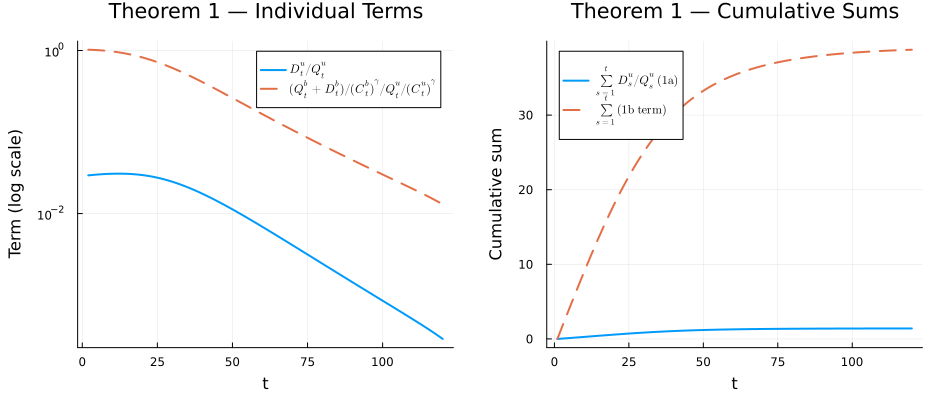

In [48]:
# ── Plot Theorem 1 conditions (1a) and (1b) ──
p1a = plot(tt[2:end], diag.cond_1a[2:end], lw=2, yscale=:log10,
           label=L"D_t^u / Q_t^u", xlabel="t", ylabel="Term (log scale)",
           title="Theorem 1 — Individual Terms")
plot!(p1a, tt[2:end], diag.cond_1b[2:end], lw=2, ls=:dash,
      label=L"(Q_t^b+D_t^b)/(C_t^b)^\gamma / Q_t^u/(C_t^u)^\gamma")

p1b = plot(tt, sum_1a[tt], lw=2,
           label=L"\sum_{s=1}^t D_s^u/Q_s^u\ (\mathrm{1a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Theorem 1 — Cumulative Sums")
plot!(p1b, tt, sum_1b[tt], lw=2, ls=:dash,
      label=L"\sum_{s=1}^t \mathrm{(1b\ term)}")

plot(p1a, p1b, layout=(1,2), size=(950, 400), margin=5Plots.mm)

## 1. Corollary 1 — Primitive Conditions (V7)

Corollary 1 (V7) reduces the Theorem 1 conditions to primitive (exogenous) quantities using Lemmas 1–6.

### Condition (2a): $\sum_{t=1}^\infty D_t^u / e_{US,t}^u < \infty$

Equivalent to Theorem 1 condition (1a) since $Q_t^u \propto e_t^u$ by Lemma 1 (V7). This is a geometric series with ratio $g_{D,u}/g_{e,u}$, converging iff $g_{D,u} < g_{e,u}$ (1.5% < 2.5% annual).

### Condition (2b): $\sum_{t=1}^\infty (e_t^b / e_t^u)^{1-\gamma} < \infty$

Equivalent to Theorem 1 condition (1b) since $Q_t^z, C_t^z \propto e_t^z$ by Lemmas 1 and 6 (V7). The code computes $(C_t^b/C_t^u)^{1-\gamma}$, which is proportional to $(e_t^b/e_t^u)^{1-\gamma}$ under the equilibrium bounds. With Assumption 7 (V7) scaling: $e_t^b = \lambda_e \rho^t \cdot e_t^u$, so the terms are $(\lambda_e \rho^t)^{1-\gamma}$.

In [49]:
println("══ Corollary 1 Results ══")
@printf("  Condition (2a):  Σ D^u/e^u = %.6f\n", diag.sum_dividend_ratio[end])
@printf("    Converges: %s\n", diag.condition_2a_converges)
@printf("  Condition (2b):  Σ (C^b/C^u)^{1-γ} = %.6f\n", diag.sum_cond_2b[end])
@printf("    Converges: %s\n", diag.condition_2b_converges)
println()
@printf("  ⟹  BUBBLE EXISTS: %s\n", diag.bubble_exists)
@printf("  Total leakage Σ aₜ = %.6f\n", diag.sum_a_t[end])

══ Corollary 1 Results ══
  Condition (2a):  Σ D^u/e^u = 0.793826
    Converges: true
  Condition (2b):  Σ (C^b/C^u)^{1-γ} = 46.989560
    Converges: false

  ⟹  BUBBLE EXISTS: false
  Total leakage Σ aₜ = 18.018164


## 2. Four-Panel Diagnostic Plot

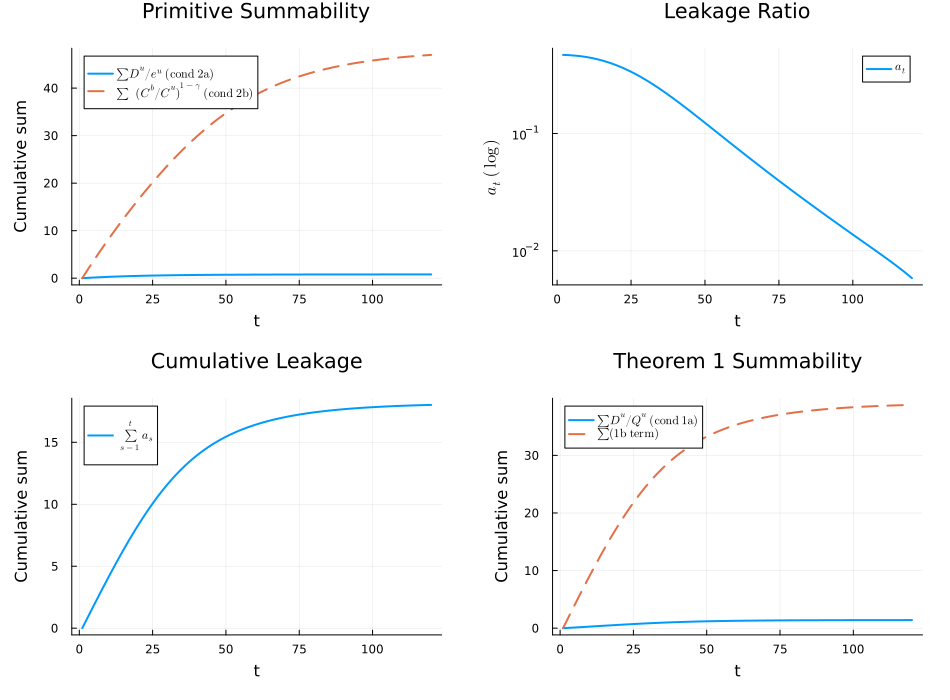

In [50]:
# ── Panel 1: Cumulative Summability Conditions ──
dp1 = plot(tt, diag.sum_dividend_ratio[tt], lw=2, label=L"\sum D^u/e^u\ (\mathrm{cond\ 2a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Primitive Summability")
plot!(dp1, tt, diag.sum_cond_2b[tt], lw=2, ls=:dash,
      label=L"\sum (C^b/C^u)^{1-\gamma}\ (\mathrm{cond\ 2b})")

# ── Panel 2: Individual Leakage Terms ──
dp2 = plot(tt[2:end], diag.a_t[2:end], lw=2, label=L"a_t", yscale=:log10,
           xlabel="t", ylabel=L"a_t\ (\log)",
           title="Leakage Ratio")

# ── Panel 3: Cumulative Leakage ──
dp3 = plot(tt, diag.sum_a_t[tt], lw=2, label=L"\sum_{s=1}^t a_s",
           xlabel="t", ylabel="Cumulative sum",
           title="Cumulative Leakage")

# ── Panel 4: Theorem 1 Conditions (1a) and (1b) ──
sum_1a = cumsum(diag.cond_1a)
sum_1b = cumsum(diag.cond_1b)
dp4 = plot(tt, sum_1a[tt], lw=2, label=L"\sum D^u/Q^u\ (\mathrm{cond\ 1a})",
           xlabel="t", ylabel="Cumulative sum",
           title="Theorem 1 Summability")
plot!(dp4, tt, sum_1b[tt], lw=2, ls=:dash,
      label=L"\sum \mathrm{(1b\ term)}")

plot(dp1, dp2, dp3, dp4, layout=(2,2), size=(950, 700), margin=5Plots.mm)

## 3. Fundamental Value Decomposition

The US stock price decomposes as
$$Q_{US,t} = \underbrace{V_{US,t}}_{\text{fundamental}} + \underbrace{B_{US,t}}_{\text{bubble}}.$$

We compute $V_t$ by backward discounting of dividends using the **effective pricing kernel** $\mathcal{M}_{t,t+1} = \mathcal{K}_{t,t+1}/\Psi_t$ (V7), where the portfolio wedge is:
$$\Psi_t = 1 - \lambda_t + \phi_t(1-\omega_t), \qquad \phi_t = \frac{\kappa}{\beta(1-\theta_t)}(\omega_t - \bar\omega), \qquad \lambda_t = \frac{\eta\theta_t}{\beta}\Upsilon'(\theta_t)$$

In [24]:
# ── Compute fundamental value by backward recursion ──
# In balanced state b, Q = V (no bubble by Proposition 1, V7), so V_T = Q^b_T.
# Q^b_T = Q_US_hat * λ_e_T * e_US^u_T  (Q_US_hat is normalised by e_US^b)

V = zeros(T)
λ_e_T = p.λ_e * p.ρ^T
V[T] = bs[T].Q_US_hat * λ_e_T * paths.e_US[T]

for t in (T-1):-1:1
    s = u_path[t]
    λ_e_tp1 = p.λ_e * p.ρ^(t + 1)
    λ_D_tp1 = p.λ_D * p.ρ_D^(t + 1)

    V_u_next = V[t+1]
    D_u_next = paths.D_US[t+1]

    # Q^b_{t+1} = Q_US_hat * λ_e_{t+1} * e_US^u_{t+1}
    V_b_next = bs[t+1].Q_US_hat * λ_e_tp1 * paths.e_US[t+1]
    D_b_next = λ_D_tp1 * paths.D_US[t+1]

    Q_US_next_u = u_path[t+1].Q_US
    Q_W_next_u  = u_path[t+1].Q_W
    Q_US_next_b = bs[t+1].Q_US_hat * λ_e_tp1 * paths.e_US[t+1]
    Q_W_next_b  = bs[t+1].Q_W_hat  * λ_e_tp1 * paths.e_US[t+1]

    ret_u = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_u, Q_W_next_u,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)
    ret_b = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_b, Q_W_next_b,
                D_b_next, paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)

    M_u, M_b = us_kernel(ret_u.R_A, ret_b.R_A, p.γ, p.π_persist)

    # Effective kernel: M_eff = K / Ψ_t  (V7 eq. for effective_US_kernel)
    # Ψ_t = 1 - λ_t + φ_t(1 - ω_t)
    # φ_t = κ / (β(1-θ)) * (ω - ω̄)
    # λ_t = (η θ / β) Υ'(θ)
    phi = p.κ / (p.β * (1 - s.θ)) * (s.ω - p.ω̄)
    lambda_t = p.η * s.θ / p.β * upsilon_prime(DEFAULT_COST, s.θ)
    Psi_t = 1 - lambda_t + phi * (1 - s.ω)
    Meff_u = M_u / Psi_t
    Meff_b = M_b / Psi_t

    V[t] = p.π_persist * Meff_u * (V_u_next + D_u_next) +
           (1 - p.π_persist) * Meff_b * (V_b_next + D_b_next)
end

B = Q_US_vec .- V
bubble_share = B ./ Q_US_vec

@printf("At t=1:  Q_US = %.4e,  V = %.4e,  B = %.4e,  B/Q = %.4f\n",
        Q_US_vec[1], V[1], B[1], bubble_share[1])

At t=1:  Q_US = 6.1521e-01,  V = 6.1521e-01,  B = 8.2978e-07,  B/Q = 0.0000


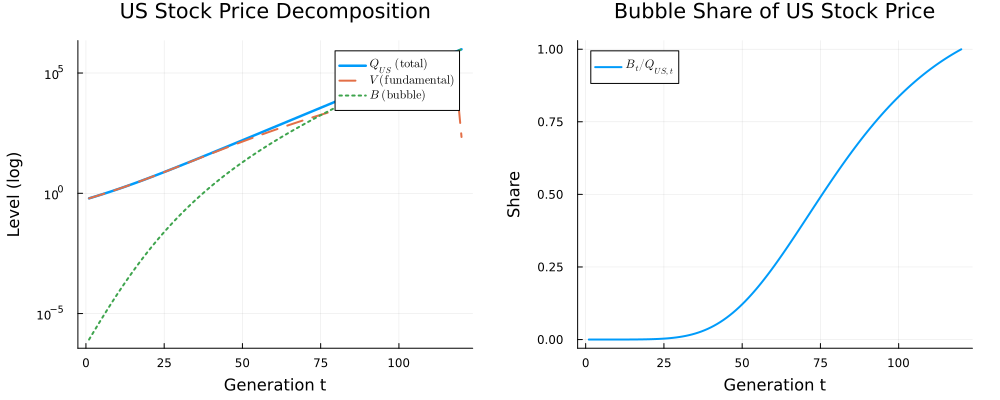

In [25]:
# ── Price Decomposition Plot ──
fp1 = plot(tt, Q_US_vec, label=L"Q_{US}\ (\mathrm{total})", lw=2.5, yscale=:log10,
           xlabel="Generation t", ylabel="Level (log)",
           title="US Stock Price Decomposition")
plot!(fp1, tt, V, label=L"V\ (\mathrm{fundamental})", lw=2, ls=:dash)
plot!(fp1, tt, max.(B, 1e-20), label=L"B\ (\mathrm{bubble})", lw=2, ls=:dot)

fp2 = plot(tt, bubble_share, lw=2, label=L"B_t / Q_{US,t}",
           xlabel="Generation t", ylabel="Share",
           title="Bubble Share of US Stock Price")

plot(fp1, fp2, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

## 4. Detailed Leakage Analysis

From the proof of Theorem 1 (V7), the leakage ratio decomposes as:

$$a_t = \underbrace{\frac{D_t^u}{Q_t^u}}_{\text{dividend leakage}} + \underbrace{\frac{1-\pi}{\pi}\left(\frac{C_t^u}{C_t^b}\right)^{\gamma}\frac{Q_t^b + D_t^b}{Q_t^u}}_{\text{switch leakage}}$$

where the switch leakage uses $\mathcal{M}^b_{t-1,t}/\mathcal{M}^u_{t-1,t} = (C_t^u/C_t^b)^\gamma$ (the $\Psi_{t-1}$ wedge cancels across states since $\omega_{t-1}, \theta_{t-1}$ are $\mathcal{F}_{t-1}$-measurable, V7 Assumption 5).

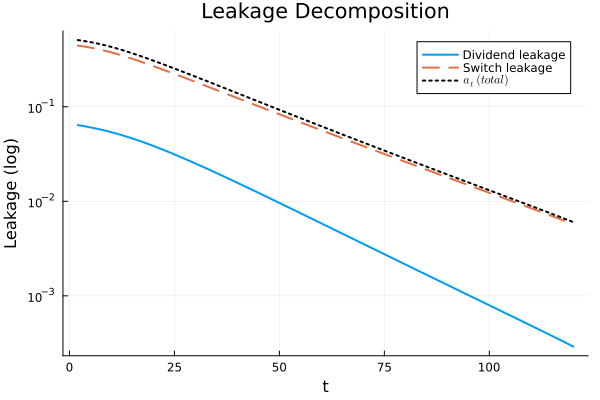

In [26]:
# ── Decompose leakage into dividend and switch components ──
div_leak   = diag.cond_1a       # D^u/Q^u
switch_leak = diag.a_t .- diag.cond_1a

dp_leak = plot(tt[2:end], div_leak[2:end], lw=2, label="Dividend leakage",
               yscale=:log10, xlabel="t", ylabel="Leakage (log)",
               title="Leakage Decomposition")
plot!(dp_leak, tt[2:end], switch_leak[2:end], lw=2, ls=:dash, label="Switch leakage")
plot!(dp_leak, tt[2:end], diag.a_t[2:end], lw=2, ls=:dot, lc=:black, label=L"a_t\ (total)")

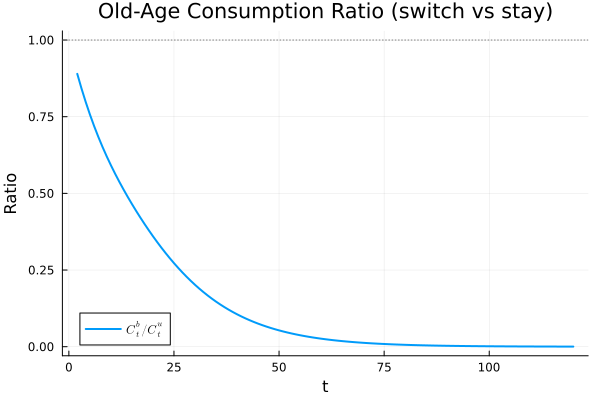

In [27]:
# ── Consumption ratio across regimes ──
# C^b_t / C^u_t = R_A^b / R_A^u  at date t
# B-state: Q^b = Q_US_hat * λ_e_t * e_US^u,  D^b = λ_D_t * D^u
consump_ratio = zeros(T)
for t in 2:T
    s_prev = u_path[t-1]
    λ_e_t = p.λ_e * p.ρ^t
    λ_D_t = p.λ_D * p.ρ_D^t

    ret_u = compute_returns(s_prev.Q_US, s_prev.Q_W,
                u_path[t].Q_US, u_path[t].Q_W,
                paths.D_US[t], paths.D_W[t],
                s_prev.ω, s_prev.ω_star,
                s_prev.θ, s_prev.θ_US_star, s_prev.R_f)

    Q_US_b = bs[t].Q_US_hat * λ_e_t * paths.e_US[t]
    Q_W_b  = bs[t].Q_W_hat  * λ_e_t * paths.e_US[t]
    D_US_b = λ_D_t * paths.D_US[t]
    ret_b = compute_returns(s_prev.Q_US, s_prev.Q_W,
                Q_US_b, Q_W_b,
                D_US_b, paths.D_W[t],
                s_prev.ω, s_prev.ω_star,
                s_prev.θ, s_prev.θ_US_star, s_prev.R_f)

    consump_ratio[t] = ret_b.R_A / ret_u.R_A
end

cr_plot = plot(tt[2:end], consump_ratio[2:end], lw=2,
              label=L"C^b_t / C^u_t",
              xlabel="t", ylabel="Ratio",
              title="Old-Age Consumption Ratio (switch vs stay)")
hline!(cr_plot, [1.0], ls=:dot, lc=:gray, label="")


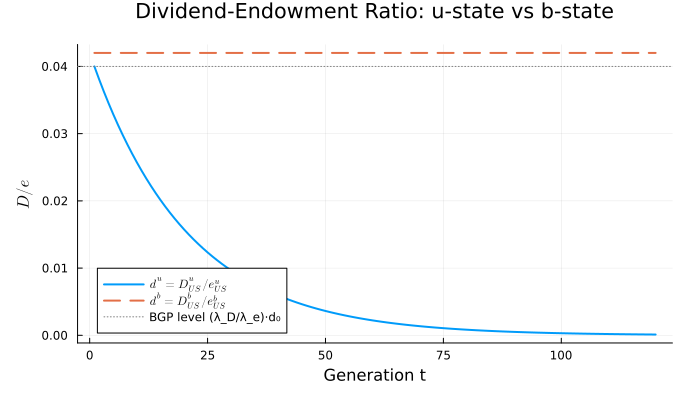

In [28]:
# ── Dividend-endowment ratio: u-state vs b-state ──
# d^b_t = D^b_t / e^b_t = (λ_D·ρ_D^t · D^u_t) / (λ_e·ρ^t · e^u_t)
#        = (λ_D/λ_e) · (ρ_D/ρ)^t · d^u_t
# With ρ_D = g_e_b/g_D_u and ρ = g_e_b/g_e_u:
#   (ρ_D/ρ)^t · (g_D_u/g_e_u)^t = (ρ_D·g_D_u/(ρ·g_e_u))^t = (g_e_b/g_e_b)^t = 1
# ⟹  d^b_t = (λ_D/λ_e) · d_0  (constant — genuine BGP)
div_endow_u = [paths.D_US[t] / paths.e_US[t]                         for t in tt]
div_endow_b = [(p.λ_D * p.ρ_D^t) / (p.λ_e * p.ρ^t) * paths.D_US[t] / paths.e_US[t]
               for t in tt]

de_plot = plot(tt, div_endow_u, lw=2,
               label=L"d^u = D_{US}^u / e_{US}^u",
               xlabel="Generation t",
               ylabel=L"D/e",
               title="Dividend-Endowment Ratio: u-state vs b-state")
plot!(de_plot, tt, div_endow_b, lw=2, ls=:dash,
      label=L"d^b = D_{US}^b / e_{US}^b")
hline!(de_plot, [p.D_e_ratio_0 * p.λ_D / p.λ_e], ls=:dot, lc=:gray,
        label="BGP level (λ_D/λ_e)·d₀")
plot!(de_plot, size=(700, 400), margin=5Plots.mm)


The key to understanding $C_t^b/C_t^u$ lies in the **stock market clearing condition** and the **W stock channel**.

### Why $C^b/C^u$ can exceed 1

**1. Total stock value is conserved across states.** From the aggregate market-cap identity (V7):

$$
Q_{US,t}+Q_{W,t}
=
\beta e_{US,t}
+\frac{\beta+\chi}{1+\chi}\,e_{W,t}.
$$

This is the same in both states $u$ and $b$ (when $\lambda_e = 1$, endowments are identical). The bubble doesn't create or destroy aggregate stock value — it only **reallocates** between US and W stocks:

$$Q_{US}^u - Q_{US}^b = Q_W^b - Q_W^u \equiv \Delta > 0$$

**2. The percentage impacts are asymmetric.** The same dollar amount $\Delta$ is added to US stock and subtracted from W stock, but since $Q_W < Q_{US}$, the **percentage depression** of the W stock is larger than the percentage inflation of the US stock.

**3. Portfolio return decomposition.** The consumption ratio is:

$$\frac{C^b}{C^u} = \frac{R_A^b}{R_A^u}, \quad \text{where } R_A = (1-\theta)[\omega R_{US} + (1-\omega)R_W] + \theta R_f$$

The return difference across states is:

$$R_A^b - R_A^u = (1-\theta)\left[\underbrace{-\omega \frac{\Delta}{Q_{US,t-1}^u}}_{\text{US stock loss}} + \underbrace{(1-\omega)\frac{\Delta}{Q_{W,t-1}^u}}_{\text{W stock gain}}\right]$$

So $C^b/C^u > 1$ when the **W stock recovery effect** dominates:

$$(1-\omega)\frac{1}{Q_{W,t-1}^u} > \omega \frac{1}{Q_{US,t-1}^u}$$

This simplifies to:

$$\frac{1-\omega}{\omega} > \frac{Q_{W,t-1}^u}{Q_{US,t-1}^u}$$

**4. When does this hold?** With $\bar\omega = 0.80$ (US home bias target), $\omega^u$ is around 0.8. So the LHS $\approx 0.25$. But $Q_W/Q_{US}$ depends on relative country sizes and can be smaller than 0.25, especially when the bubble makes $Q_{US}^u$ large relative to $Q_W^u$. In those periods, the W stock is so depressed that its percentage recovery upon switching to $b$ more than compensates for the US stock crash — producing $C^b/C^u > 1$.

### Intuition

The intuition ("bursting should hurt") is correct for the **US stock component** in isolation. But the bubble *simultaneously depresses* the W stock (the zero-sum reallocation), and old agents hold both stocks. When the bubble bursts, the W stock **recovers** by the same dollar amount. Because the W stock was depressed to a lower base, its percentage recovery is larger, and this can fully offset (or even dominate) the US stock loss for the portfolio as a whole.

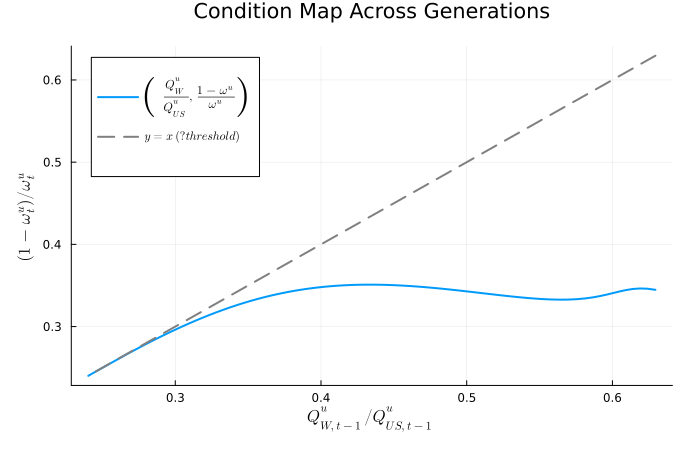

In [29]:
# ── Condition Plot: (1-ω)/ω vs Q_W^u / Q_US^u ──
ω_u_vec = [u_path[t].ω for t in tt]
lhs = (1 .- ω_u_vec) ./ ω_u_vec
rhs = Q_W_vec ./ Q_US_vec

cond_plot = plot(rhs, lhs, lw=2,
                 xlabel=L"Q_{W,t-1}^u / Q_{US,t-1}^u",
                 ylabel=L"(1-\omega_t^u)/\omega_t^u",
                 label=L"\left(\frac{Q_W^u}{Q_{US}^u},\frac{1-\omega^u}{\omega^u}\right)",
                 title="Condition Map Across Generations")

plot!(cond_plot, rhs, rhs, lw=2, ls=:dash, lc=:gray,
      label=L"y=x\ (\text{threshold})")

plot!(cond_plot, size=(700, 450), margin=5Plots.mm)

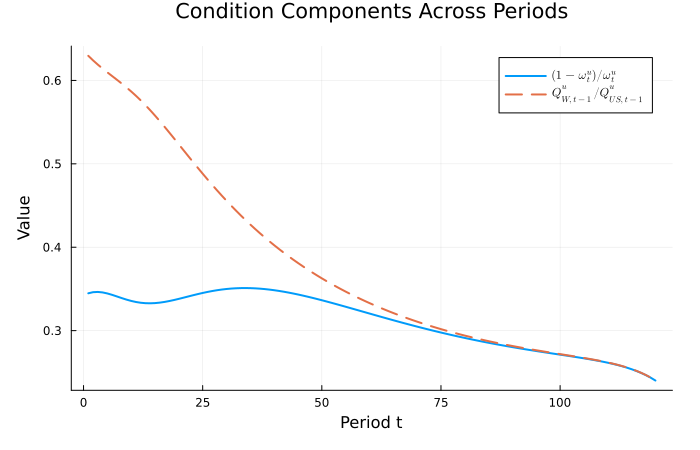

In [30]:
# ── Replot: both series against periods ──
ω_u_vec = [u_path[t].ω for t in tt]
lhs = (1 .- ω_u_vec) ./ ω_u_vec
rhs = Q_W_vec ./ Q_US_vec

ts_plot = plot(tt, lhs, lw=2,
               xlabel="Period t",
               ylabel="Value",
               label=L"(1-\omega_t^u)/\omega_t^u",
               title="Condition Components Across Periods")

plot!(ts_plot, tt, rhs, lw=2, ls=:dash,
      label=L"Q_{W,t-1}^u / Q_{US,t-1}^u")

plot!(ts_plot, size=(700, 450), margin=5Plots.mm)

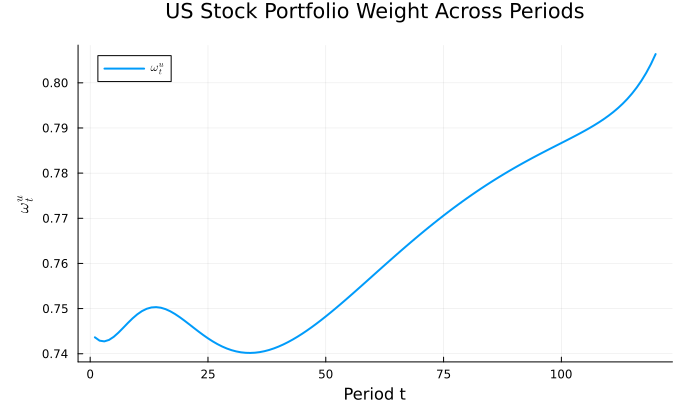

In [31]:
# ── Plot only ω_t^u against periods ──
ω_u_vec = [u_path[t].ω for t in tt]

ω_plot = plot(tt, ω_u_vec, lw=2,
              xlabel="Period t",
              ylabel=L"\omega_t^u",
              label=L"\omega_t^u",
              title="US Stock Portfolio Weight Across Periods")

plot!(ω_plot, size=(700, 420), margin=5Plots.mm)



The core issue is that with the current default $\lambda_e = 1$, $\lambda_D = 1$, the bubble burst has no real-sector impact — it's a pure asset reallocation. The W stock recovery fully offsets the US stock crash. Several parameter changes can fix this:

### Most direct: $\lambda_e < 1$ and/or $\lambda_D < 1$

These parameters (Assumption 7, V7) represent real damage from the bubble burst:
- $\lambda_e = e_{US}^b / e_{US}^u < 1$: US endowments shrink when the bubble pops
- $\lambda_D = D_{US}^b / D_{US}^u < 1$: US dividends shrink when the bubble pops

With Assumption 7 decay: the effective scalings at switch date $\tau$ are $\lambda_e \rho^\tau$ and $\lambda_D \rho_D^\tau$, where $\rho = g_b/g_{e,u} \approx 0.929$ and $\rho_D = g_b/g_{D,u} \approx 0.976$.

From the return formulas in TwoCountryOLG.jl:

```
R_US_b = g_e * (q_US_b * λ_e_tp1 + λ_D_tp1 * d_next) / q_US
R_W_b  = g_e * (q_W_b  * λ_e_tp1 + d_W_next_hat)   / q_W
```



Both stock prices in the balanced state are scaled by $\lambda_e \rho^t$ (see TwoCountryOLG.jl, Assumption 7 V7):

$$Q_{US}^b = \hat{Q}_{US}^b \cdot \lambda_e \rho^t \cdot e_{US}^u, \qquad Q_W^b = \hat{Q}_W^b \cdot \lambda_e \rho^t \cdot e_{US}^u$$

Setting $\lambda_e < 1$ pulls **both** $R_{US}^b$ and $R_W^b$ down. The W stock recovery is muted because balanced-state prices are lower. This directly reduces $C^b/C^u = R_A^b/R_A^u$ below 1.

**Try**: `ModelParams(λ_e = 0.95, λ_D = 0.95)` — a 5% real contraction upon bursting.

### Other parameter levers

| Parameter | Direction | Mechanism |
|-----------|-----------|-----------|
| $\lambda_e$ | $\downarrow$ below 1 | Real endowment loss at burst → both stock returns fall in $b$ |
| $\lambda_D$ | $\downarrow$ below 1 | US dividend loss at burst → $R_{US}^b$ falls further |
| $\bar\omega$ | $\uparrow$ toward 1 | More portfolio in US stock → US crash dominates W recovery |
| $g_{e,W}$ | $\uparrow$ | Larger RoW → $Q_W$ bigger → W recovery's *percentage* gain is smaller |
| $\gamma$ | $\uparrow$ toward 1 | Higher risk aversion changes the kernel weighting of states |

### Why $\lambda_e < 1$ is the cleanest fix

The economic story becomes: a bubble burst has **real consequences** — productivity or income drops when the bubble collapses (e.g., misallocation correction, financial disruption). This is empirically plausible and breaks the zero-sum nature of the pure asset reallocation, ensuring $C^b < C^u$ as intuition demands. The parameter is already built into the model (Assumption 7, V7) — it just needs to be set below 1.



From the aggregate market-cap identity (V7):

$$Q_{US} + Q_W = \underbrace{\beta \, e_{US}}_{A} + \underbrace{\frac{\beta+\chi}{1+\chi}\,e_W}_{A^*}$$

The split between $Q_{US}$ and $Q_W$ is determined by portfolio demand: $Q_{US} = \omega S + \omega^* S^*$, with the remainder going to $Q_W$. Several primitives can raise $Q_W$ in level:

### 1. Increase $e_{W,0}$ (initial RoW endowment)

Currently `e_W_0 = 1.0` (same as US). Setting `e_W_0 = 3.0` or higher makes RoW savings $A^*$ larger, expanding total stock market value. Since portfolio weights are pinned by the home-bias target $\bar\omega$, the extra RoW savings flow disproportionately into $Q_W$.

### 2. Increase $g_{e,W}$ (RoW endowment growth)

Currently `g_e_W = 1.01^5` (1% annual). Raising it (e.g., `g_e_W = 1.03^5`) makes RoW grow faster, so $e_W/e_{US}$ increases over time. This progressively raises $Q_W$ relative to $Q_{US}$.

### 3. Increase $D_{W,0}/e_{W,0}$ ratio

Currently `D_W_e_W_ratio_0 = 0.04`. A higher ratio (e.g., `0.08`) makes the W stock pay larger dividends, raising its fundamental value and hence its equilibrium price.

### 4. Increase $\chi$ (convenience yield)

Currently `χ = 0.005`. The RoW savings are $A^* = \frac{\beta+\chi}{1+\chi} e_W$. Increasing $\chi$ raises $A^*$, expanding total stock value. However, $\chi$ also affects bond demand, so the effect is indirect.

### 5. Decrease $\bar\omega$ / increase $\bar\omega^*$

Currently $\bar\omega = 0.80$ and $\bar\omega^* = 0.20$. Lowering $\bar\omega$ (less US home bias) or raising $\bar\omega^*$ shifts portfolio demand away from US stocks toward W stocks.

### Recommended approach

The cleanest lever is **increasing $e_{W,0}$** — it directly scales up RoW's economic size without changing growth dynamics or preferences:




The rebound comes from the **differential growth rates** interacting with the **endogenous portfolio response**.

### The basic mechanism

With $g_{e,u} = 1.025^5 \approx 1.13$ per period (US) vs $g_{e,W} = 1.01^5 \approx 1.05$ (RoW), the relative endowment ratio evolves as:

$$\frac{e_{W,t}}{e_{US,t}} = e_{W,0}/e_{US,0} \times \left(\frac{g_{e,W}}{g_{e,u}}\right)^t$$

As the US economy grows faster than RoW in state $u$, the US eventually dominates the world stock market. The stock price ratio $Q_W^u/Q_{US}^u$ declines over time as US savings grow faster, and home-biased demand inflates $Q_{US}$ relative to $Q_W$.

### Why $C^b/C^u$ initially falls below 1

With a large enough RoW (e.g., $e_{W,0}=15$), the RoW is large enough initially that $Q_W/Q_{US}$ exceeds $(1-\omega)/\omega$, so the US stock crash dominates the W stock recovery upon bursting. This gives $C^b/C^u < 1$ as expected.

### Why it rebounds

Three forces drive the rebound:

**1. The US overtakes RoW, shrinking $Q_W/Q_{US}$.** As the US endowment growth outpaces RoW ($g_{e,u} > g_{e,W}$), the W stock becomes a small fraction of the total market again. Now the same $\Delta$ reallocation becomes a large percentage of the (small) $Q_W$ — the exact same mechanism that caused $C^b/C^u > 1$ with small RoW.

**2. Endogenous $\omega$ adjustment.** As the ratio $Q_W/Q_{US}$ falls, the bubble's presence and the home-bias friction change the equilibrium $\omega$. $\omega^u$ rises over time, making $(1-\omega)/\omega$ even smaller, reinforcing the reversal.

**3. The bubble share evolution.** The bubble $B_t/Q_t$ changes over time, affecting how large $\Delta = Q_{US}^u - Q_{US}^b$ is relative to prices. As the bubble's relative contribution stabilizes, the percentage impact on W stock returns shifts.

### How to make $C^b/C^u < 1$ permanently

You need either:

1. **Equal or higher RoW growth**: Set `g_e_W` closer to or above `g_e_u` so the RoW doesn't shrink relative to the US.

2. **Combine $e_{W,0}$ with $\lambda_e < 1$**: The $\lambda_e$ channel (Assumption 7, V7) works independently of relative country size — it directly reduces all $b$-state returns.

The most robust approach: `ModelParams(e_W_0 = 3.0, g_e_W = 1.02^5)` — a reasonably-sized RoW that doesn't shrink too fast relative to the US.

In [32]:
#result = run_simulation(ModelParams(e_W_0 = 3.0); verbose=true);



This makes the RoW economy 3× larger than the US, which is roughly realistic (US ≈ 25% of world GDP). With a larger $Q_W$, the ratio $Q_W^u/Q_{US}^u$ rises, and the condition $(1-\omega)/\omega > Q_W^u/Q_{US}^u$ is more likely to fail — meaning the US stock crash dominates the W stock recovery upon bursting, giving $C^b/C^u < 1$.

You can also combine it with $g_{e,W}$ to get a growing RoW share over time. The key insight is that the current calibration with $e_{W,0} = e_{US,0} = 1$ makes the RoW unrealistically small, which is why $Q_W/Q_{US}$ is so low.

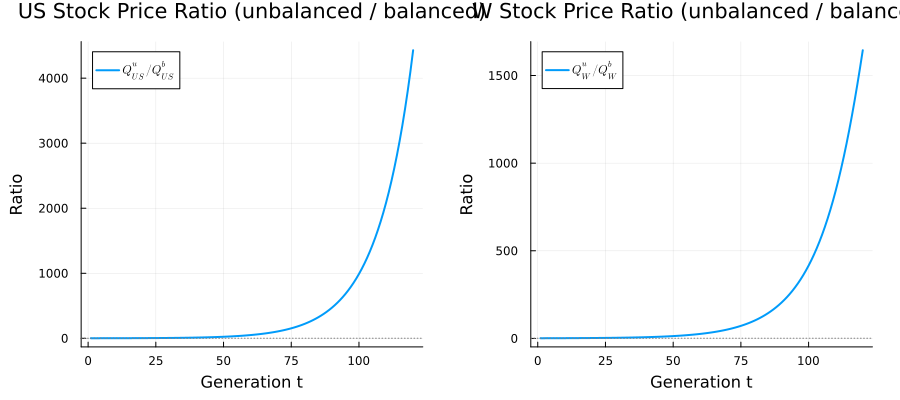

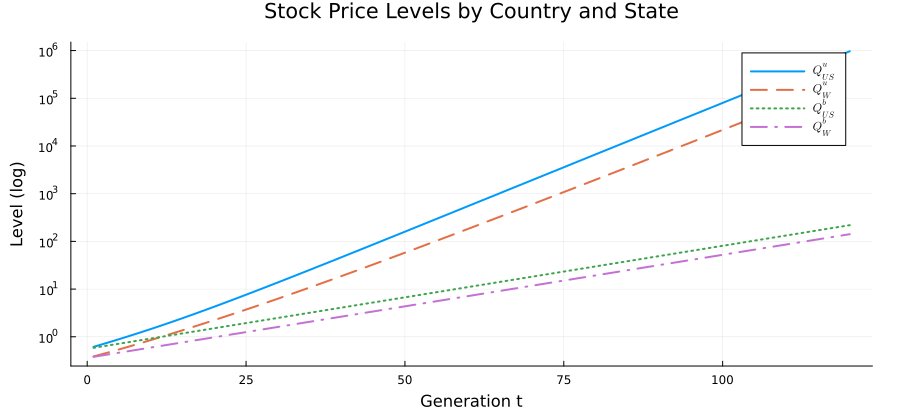

In [33]:
# ── Stock Price Ratios Across Two States ──
# Q^b_t = Q_US_hat * λ_e_t * e_US^u_t  (Q_US_hat is normalised by e_US^b, not e_US^u)
Q_US_b_vec = [bs[t].Q_US_hat * (p.λ_e * p.ρ^t) * paths.e_US[t] for t in tt]
Q_W_b_vec  = [bs[t].Q_W_hat  * (p.λ_e * p.ρ^t) * paths.e_US[t] for t in tt]
D_US_b_vec = [(p.λ_D * p.ρ_D^t) * paths.D_US[t]                for t in tt]

ratio_US = Q_US_vec ./ Q_US_b_vec
ratio_W  = Q_W_vec  ./ Q_W_b_vec

sp1 = plot(tt, ratio_US, lw=2, label=L"Q_{US}^u / Q_{US}^b",
           xlabel="Generation t", ylabel="Ratio",
           title="US Stock Price Ratio (unbalanced / balanced)")
hline!(sp1, [1.0], ls=:dot, lc=:gray, label="")

sp2 = plot(tt, ratio_W, lw=2, label=L"Q_W^u / Q_W^b",
           xlabel="Generation t", ylabel="Ratio",
           title="W Stock Price Ratio (unbalanced / balanced)")
hline!(sp2, [1.0], ls=:dot, lc=:gray, label="")

display(plot(sp1, sp2, layout=(1,2), size=(900, 400), margin=5Plots.mm))

# ── Stock Price Levels Across Two States (u and b) ──
sp_levels = plot(tt, Q_US_vec, lw=2, yscale=:log10,
                 label=L"Q_{US}^u",
                 xlabel="Generation t", ylabel="Level (log)",
                 title="Stock Price Levels by Country and State")
plot!(sp_levels, tt, Q_W_vec, lw=2, ls=:dash, label=L"Q_W^u")
plot!(sp_levels, tt, Q_US_b_vec, lw=2, ls=:dot, label=L"Q_{US}^b")
plot!(sp_levels, tt, Q_W_b_vec, lw=2, ls=:dashdot, label=L"Q_W^b")
plot!(sp_levels, size=(900, 420), margin=5Plots.mm)


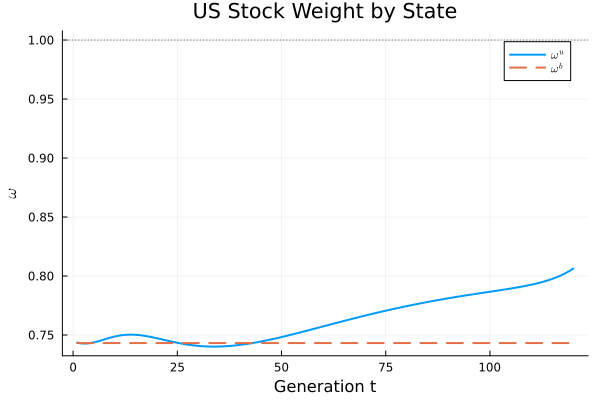

In [34]:
# ── Ratio of US to W Stock Prices in Each State ──
ratio_u = Q_US_vec ./ Q_W_vec
ratio_b = Q_US_b_vec ./ Q_W_b_vec

rp = plot(tt, ratio_u, lw=2, label=L"Q_{US}^u / Q_W^u",
          xlabel="Generation t", ylabel="Ratio",
          title="US / W Stock Price Ratio by State")
plot!(rp, tt, ratio_b, lw=2, ls=:dash, label=L"Q_{US}^b / Q_W^b")
plot!(rp, size=(700, 400), margin=5Plots.mm)

ω_u_vec = [u_path[t].ω for t in tt]
ω_b_vec = [bs[t].ω_b   for t in tt]

pw1 = plot(tt, ω_u_vec, lw=2, label=L"\omega^u",
           xlabel="Generation t", ylabel=L"\omega",
           title="US Stock Weight by State")
plot!(pw1, tt, ω_b_vec, lw=2, ls=:dash, label=L"\omega^b")
hline!(pw1, [1.0], ls=:dot, lc=:gray, label="")

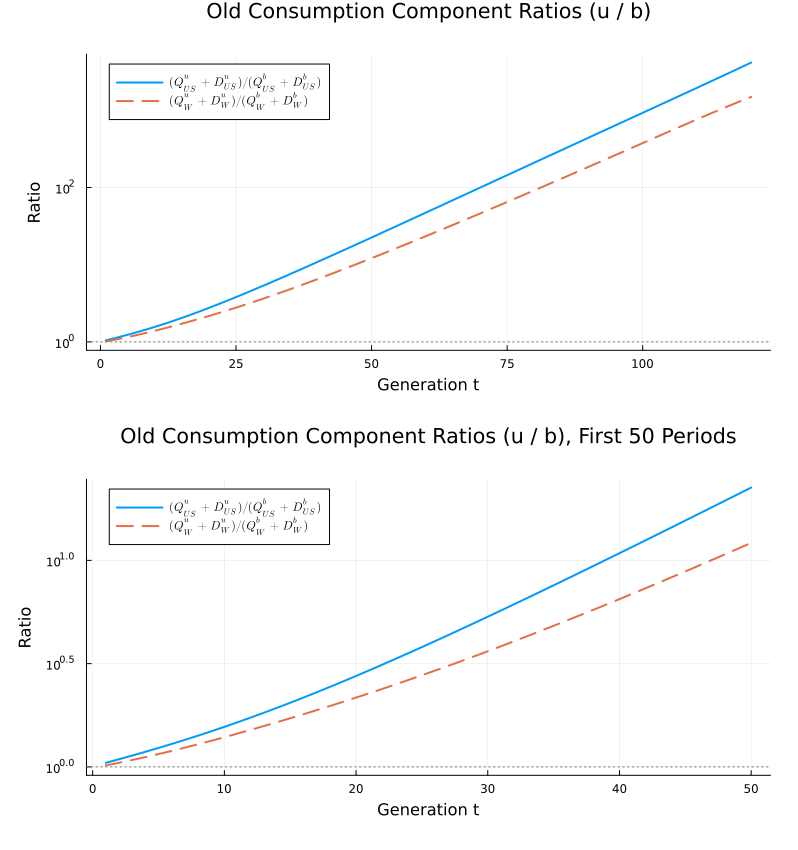

In [35]:
# ── Old Consumption Component Ratios Across Two States ──
# D_US^b = λ_D_t * D_US^u  (b-state dividend uses the ρ_D^t scaling)
ratio_US_comp = (Q_US_vec .+ paths.D_US[tt]) ./ (Q_US_b_vec .+ D_US_b_vec)
ratio_W_comp  = (Q_W_vec  .+ paths.D_W[tt])  ./ (Q_W_b_vec  .+ paths.D_W[tt])

cp = plot(tt, ratio_US_comp, lw=2, yscale=:log10,
          label=L"(Q_{US}^u + D_{US}^u) / (Q_{US}^b + D_{US}^b)",
          xlabel="Generation t", ylabel="Ratio",
          title="Old Consumption Component Ratios (u / b)")
plot!(cp, tt, ratio_W_comp, lw=2, ls=:dash, yscale=:log10,
      label=L"(Q_W^u + D_W^u) / (Q_W^b + D_W^b)")
hline!(cp, [1.0], ls=:dot, lc=:gray, label="")
plot!(cp, size=(700, 400), margin=5Plots.mm)

# First 50 periods only
tt75 = 1:min(50, T)
cp75 = plot(tt75, ratio_US_comp[tt75], lw=2, yscale=:log10,
            label=L"(Q_{US}^u + D_{US}^u) / (Q_{US}^b + D_{US}^b)",
            xlabel="Generation t", ylabel="Ratio",
            title="Old Consumption Component Ratios (u / b), First 50 Periods")
plot!(cp75, tt75, ratio_W_comp[tt75], lw=2, ls=:dash, yscale=:log10,
      label=L"(Q_W^u + D_W^u) / (Q_W^b + D_W^b)")
hline!(cp75, [1.0], ls=:dot, lc=:gray, label="")
plot!(cp75, size=(700, 400), margin=5Plots.mm)

plot(cp, cp75, layout=(2,1), size=(800, 850), margin=5Plots.mm)


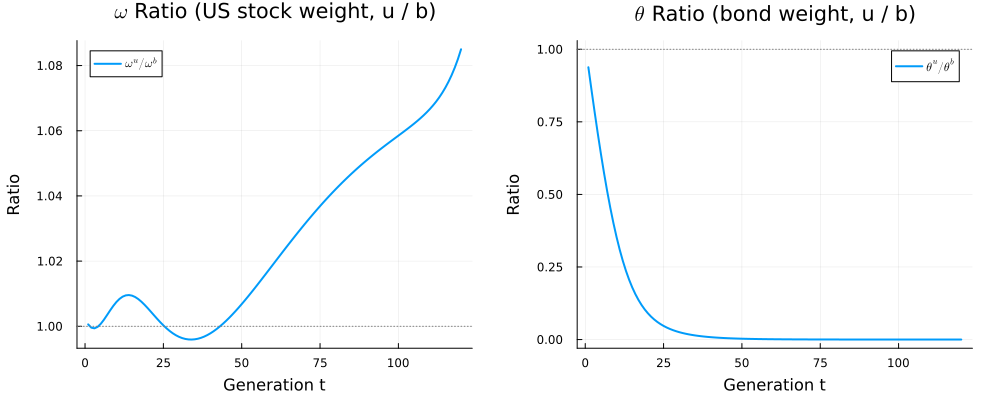

In [36]:
# ── Portfolio Weight Ratios Across Two States ──
ω_u_vec = [u_path[t].ω for t in tt]
θ_u_vec = [u_path[t].θ for t in tt]
ω_b_vec = [bs[t].ω_b   for t in tt]
θ_b_vec = [bs[t].θ_b   for t in tt]

pw1 = plot(tt, ω_u_vec ./ ω_b_vec, lw=2, label=L"\omega^u / \omega^b",
           xlabel="Generation t", ylabel="Ratio",
           title=L"\omega"*" Ratio (US stock weight, u / b)")
hline!(pw1, [1.0], ls=:dot, lc=:gray, label="")

pw2 = plot(tt, θ_u_vec ./ θ_b_vec, lw=2, label=L"\theta^u / \theta^b",
           xlabel="Generation t", ylabel="Ratio",
           title=L"\theta"*" Ratio (bond weight, u / b)")
hline!(pw2, [1.0], ls=:dot, lc=:gray, label="")

plot(pw1, pw2, layout=(1,2), size=(1000, 400), margin=5Plots.mm)

## Summary

- **Theorem 1 (V7)**: A bubble exists iff $\sum a_t < \infty$, where $a_t$ is the leakage ratio decomposed into dividend and switch components.
- **Corollary 1 (V7)** reduces Theorem 1 to primitive conditions:
  - **(2a)** (dividend summability): converges because $g_{D,u} < g_{e,u}$ (1.5% < 2.5% annual).
  - **(2b)** (endowment ratio summability): $(e_t^b/e_t^u)^{1-\gamma} = (\lambda_e \rho^t)^{1-\gamma}$; converges when $\gamma < 1$ and $\rho < 1$.
- The **fundamental value** $V_t$ is computed using the effective kernel $\mathcal{M} = \mathcal{K}/\Psi_t$ (V7), with $\Psi_t = 1 - \lambda_t + \phi_t(1-\omega_t)$ incorporating both the home-bias and bond-share wedges.
- The **bubble share** $B_t/Q_{US,t}$ shows the fraction of the US stock price attributable to the bubble.

**Next**: Notebook 05 performs comparative statics over key parameters.